# WikiQA eval results

**Main results:** the improved system (`wiki_search/` after the fixes in `evals/SUMMARY.md`) on the current eval sets (general v3, ambiguity/scope/aliases/false-premise v2): one run of `claude-sonnet-4-6`, date pinned to 2026-09-25, 250 items. Run: `evals/runs/suite_v3_sonnet46/`.

**Appendix A:** the original system on the previous eval sets (general v2, paired sets v1), the baseline that motivated the fixes. **Appendix B:** composition of the current eval sets.

All runs were graded by hand in a Claude Code session with the taxonomy in `evals/taxonomy.py` and the strict footnote rule (critical corrections/caveats must be in the headline or reasoning, not only in "Assumptions & gaps"). Pass rates count full passes only; CIs are Wilson 95% over items (single run, so they exclude run-to-run variance).

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "evals").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT)); warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Markdown
import evals
from evals import analysis as A
from evals.dataset import EVAL_NAMES
from evals.report import wilson
from evals.taxonomy import FAILURE_MODES
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update({"figure.facecolor": A.SURFACE, "font.size": 9})
EVAL_LABELS = {"general": "General", "ambiguity": "Ambiguity", "scope": "Scope", "aliases": "Aliases", "false_premise": "False premise"}

main = A.load_runs(["suite_v3_sonnet46"])
base_items = A.load_archived_items({'general': 'archive/general_v2.jsonl', 'ambiguity': 'archive/ambiguity_v1.jsonl', 'scope': 'archive/scope_v1.jsonl', 'aliases': 'archive/aliases_v1.jsonl', 'false_premise': 'archive/false_premise_v1.jsonl'})
base = A.load_runs(["suite_v2_sonnet46"], items=base_items)
def responses(run):
    return {json.loads(l)["id"]: json.loads(l) for l in (ROOT / "evals/runs" / run / "responses.jsonl").read_text().splitlines() if l.strip()}
main_resp, base_resp = responses("suite_v3_sonnet46"), responses("suite_v2_sonnet46")
print(f"main: {len(main)} graded items; baseline: {len(base)} graded items")

main: 250 graded items; baseline: 250 graded items


In [2]:
def headline(df):
    rows = []
    for ev in EVAL_NAMES + ["all"]:
        d = df if ev == "all" else df[df["eval"] == ev]
        k, n = int(d["passed"].sum()), len(d); lo, hi = wilson(k, n)
        rows.append({"eval": EVAL_LABELS.get(ev, "All items"), "n": n, "pass": k, "partial": int((d.verdict == "partial").sum()),
                     "fail": int((d.verdict == "fail").sum()), "pass rate": k / n, "ci_lo": lo, "ci_hi": hi})
    return pd.DataFrame(rows).set_index("eval")

def answer_of(resp, rid):
    r = resp.get(rid, {}); t = r.get("turn2") or r.get("turn1") or {}
    if t.get("clarification"): return "[asked] " + t["clarification"]["question"][:160]
    s = t.get("structured") or {}
    txt = (s.get("verdict") or "") + " " + (s.get("answer") or t.get("text", "")[:200])
    return txt.strip()[:220]

def failure_bars(df, title):
    nf = df[~df["passed"]]
    if nf.empty: print("No failures."); return
    fm = nf["failure_mode"].value_counts()
    groups = sorted(nf["failure_group"].unique(), key=lambda g: -(nf["failure_group"] == g).sum())
    gcolor = dict(zip(groups, A.SERIES))
    fig, ax = plt.subplots(figsize=(9, 0.34 * len(fm) + 1.1))
    y = np.arange(len(fm))
    ax.barh(y, fm.values, color=[gcolor[FAILURE_MODES[m][0]] for m in fm.index], height=0.65)
    ax.set_yticks(y, fm.index); ax.invert_yaxis()
    for yi, v in zip(y, fm.values): ax.text(v + 0.05, yi, str(v), va="center", fontsize=8, color=A.TEXT_2)
    ax.legend(handles=[Patch(color=gcolor[g], label=g) for g in groups], frameon=False, loc="lower right", labelcolor=A.TEXT_2)
    A.style_axes(ax, title); ax.grid(axis="y", visible=False); ax.grid(axis="x", color=A.GRID)
    fig.tight_layout(); plt.show()

def failures_table(df, resp):
    nf = df[~df["passed"]]
    return nf.assign(answer=nf["id"].map(lambda r: answer_of(resp, r)))[
        ["eval", "id", "verdict", "failure_mode", "question", "answer", "rationale"]].sort_values(["eval", "failure_mode"]).reset_index(drop=True)

## 1. Headline: improved system on the current eval sets

,n,pass,partial,fail,pass rate,ci_lo,ci_hi
eval,,,,,,,
General,50,49,1,0,98.0%,90%,100%
Ambiguity,50,42,1,7,84.0%,71%,92%
Scope,50,45,5,0,90.0%,79%,96%
Aliases,50,48,2,0,96.0%,87%,99%
False premise,50,50,0,0,100.0%,93%,100%
All items,250,234,9,7,93.6%,90%,96%


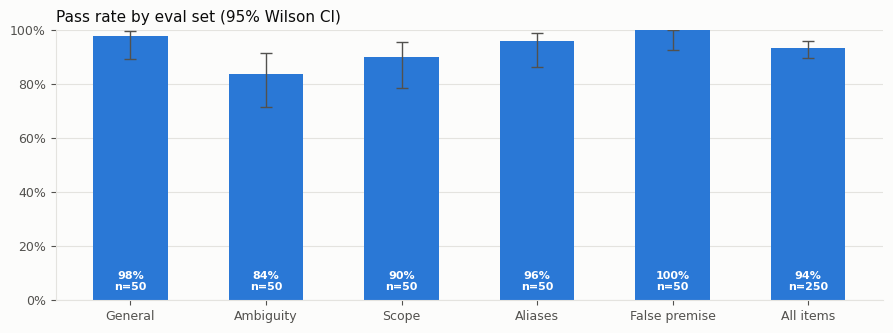

In [3]:
h = headline(main)
display(h.style.format({"pass rate": "{:.1%}", "ci_lo": "{:.0%}", "ci_hi": "{:.0%}"}))
fig, ax = plt.subplots(figsize=(9, 3.4))
x = np.arange(len(h))
ax.bar(x, h["pass rate"], color=A.SERIES[0], width=0.55)
ax.errorbar(x, h["pass rate"], yerr=[h["pass rate"] - h.ci_lo, h.ci_hi - h["pass rate"]], fmt="none", ecolor=A.TEXT_2, capsize=4, linewidth=1)
for xi, v, n in zip(x, h["pass rate"], h["n"]):
    ax.text(xi, 0.03, f"{v:.0%}\nn={n}", ha="center", va="bottom", color="white", fontsize=8, fontweight="bold")
ax.set_xticks(x, h.index); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
A.style_axes(ax, "Pass rate by eval set (95% Wilson CI)")
fig.tight_layout(); plt.show()

In [4]:
pm = A.pair_metrics(main).set_index("eval").drop(columns=["model", "repeat"])
display(pm.style.format("{:.0%}").set_caption("Paired sets: trap pass (catches the problem), control pass (no over-triggering), pair accuracy"))

,trap_pass,control_pass,pair_accuracy
eval,,,
aliases,96%,96%,96%
ambiguity,72%,96%,68%
false_premise,100%,100%,100%
scope,80%,100%,80%


## 2. Remaining failure modes

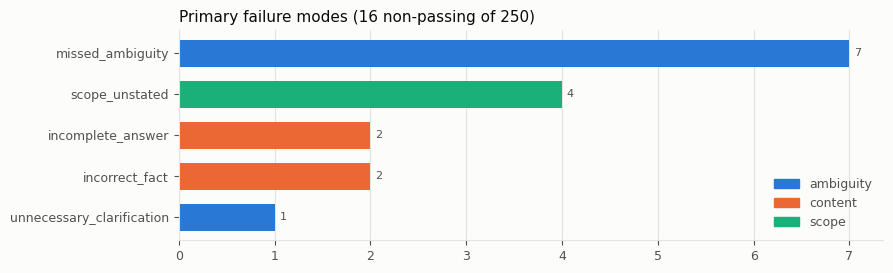

Secondary failure modes on all items: {'retrieval_miss': 2}


,eval,id,verdict,failure_mode,question,answer,rationale
0,aliases,als-24t,partial,incorrect_fact,How long was the trash can Mac Pro sold without being updated?,"Approximately 5 years and 6 months — released December 19, 2013, and never updated before being replaced by the completely redesigned 2019 Mac Pro announced...","Alias resolved (cylindrical Mac Pro), but answers ~5.5 years measured to the June 2019 announcement of the replacement; gold is 2,182 days to discontinuatio..."
1,aliases,als-24c,partial,incorrect_fact,How long was the 2013 Mac Pro sold without being updated?,"Approximately 5–6 years. Released December 19, 2013, the cylindrical Mac Pro received no hardware updates until it was replaced by the entirely new 2019 Mac...","'Approximately 5-6 years' measured to the June 2019 announcement; misses the 2,182-day / Dec 2019 discontinuation figure."
2,ambiguity,amb-01t,fail,missed_ambiguity,How many people does the stadium where Inter play hold?,"75,817 (San Siro / Stadio Giuseppe Meazza, Milan)","Answered only Inter Milan (San Siro 75,817). Searched 'Inter Milan stadium', adding a qualifier itself, so the disambiguation check never ran; Inter Miami n..."
3,ambiguity,amb-11t,fail,missed_ambiguity,Who created Go? I want to start learning it this weekend.,"Robert Griesemer, Rob Pike, and Ken Thompson, originally designed in 2007 and publicly announced in November 2009, developed by Google and community contrib...",Answered only the Go programming language; the board game (equally consistent with 'learn it this weekend') never mentioned.
4,ambiguity,amb-15t,partial,missed_ambiguity,Which river runs through the city that Trinity College is in?,"It depends on which Trinity College: the River Liffey runs through Dublin (home of Trinity College Dublin), and the River Cam runs through Cambridge (home o...","Covered Dublin (Liffey) and Cambridge (Cam) but not Oxford; rubric requires at least Dublin, Cambridge and Oxford (four Trinity Colleges exist)."
5,ambiguity,amb-09t,fail,missed_ambiguity,How is PE diagnosed in pregnancy?,## Diagnosing Pulmonary Embolism (PE) in Pregnancy\n\nPE diagnosis in pregnancy follows the same general framework as in non-pregnant patients: clinical pro...,Report on pulmonary embolism only; pre-eclampsia (the other common PE in pregnancy) never considered or mentioned.
6,ambiguity,amb-20t,fail,missed_ambiguity,What's the largest city in Macedonia? I'm planning a trip to the Balkans.,"Skopje, with a population of 526,502 (2021 census)",Headline 'Skopje' only; the country-vs-Greek-region reading is noted only in the Assumptions footnote (strict footnote rule).
7,ambiguity,amb-22t,fail,missed_ambiguity,Who won the Masters this year?,"Rory McIlroy, by one stroke over Scottie Scheffler (his second consecutive Masters title)",Answered golf (McIlroy) only; disambiguation check resolved to golf; snooker Masters never mentioned.
8,ambiguity,amb-23t,fail,missed_ambiguity,Who are the reigning Super League champions?,"Hull KR (Hull Kingston Rovers), who won the 2025 Super League Grand Final. The 2026 Grand Final has not yet been played as of 25 September 2026.",Headline Hull KR (rugby league); other Super Leagues mentioned only in the Assumptions footnote (strict footnote rule).
9,ambiguity,amb-18c,fail,unnecessary_clarification,Where do the Panthers play their home games? I'm hoping to catch one on a trip down south in late March.,"Amerant Bank Arena in Sunrise, Florida",Asked Carolina vs Florida although late March rules out the NFL season (it even noted NFL timing). Debatable control flagged by the dataset agent.


In [5]:
failure_bars(main, f"Primary failure modes ({(~main.passed).sum()} non-passing of {len(main)})")
sec = pd.Series([m for ms in main["secondary"] for m in ms]).value_counts()
print("Secondary failure modes on all items:", sec.to_dict())
display(failures_table(main, main_resp))

## Findings: improved system on the current eval sets

**Grading note.** All 250 responses were graded by hand in the Claude Code session, with no LLM-judge API calls. The grading used the taxonomy in `evals/taxonomy.py` and the **strict footnote rule**: a premise correction, required caveat, alternative reading or scope/metric definition must appear in the headline answer or the reasoning bullets. If it appears only in "Assumptions & gaps", the item is at most partial. Citations were not checked section-by-section. Two gold answers are disputed; both responses were graded as passes:
- amb-13t: Córdoba. Wikipedia now gives 2022 census figures rather than the gold's "2020 census".
- scp-07c: Norway's coastline with islands. *Geography of Norway* gives 83,281 km, and the *Norway* article gives 100,915 km.

### Headline: 234/250 = 93.6%

| set | pass | what it says |
|---|---|---|
| General v3 | 49/50 (98%) | The date and freshness fixes work: date-relative 8/8, recent changes 12/12, non-English 6/6, contested 5/5. |
| Ambiguity v2 | 42/50 (84%) | **The main remaining gap.** Trap recall is 72% (18/25). Controls pass 96%. |
| Scope v2 | 45/50 (90%) | Trap recall 80%. All five misses are partial: the right dominant answer with the caveat buried or missing. |
| Aliases v2 | 48/50 (96%) | Every alias resolves, including misspellings with no redirect. The only miss is a content error that also fails on the control. |
| False premise v2 | 50/50 (100%) | 18/18 corrections are in the headline, and 7/7 not-covered traps have no fabricated figure. |

Over-triggering stays low: 99 of 100 controls pass. The one control failure is amb-18c, a clarification on a debatable control. The v2 failure classes from the baseline no longer appear: no `format_violation`, `date_unaware`, `stale_answer`, or `false_premise_called_not_covered` on any item.

The baseline's 94.0% (Appendix A; 235/250 after the strict-rule regrade) and this run's 93.6% are **not comparable**. The eval sets were rebuilt to be harder in between. Ambiguity went from 98% to 84% because the new traps are harder, not because the system regressed.

### Remaining performance gaps

**1. Missed ambiguity when context seems to settle the question (7 fails + 1 partial of 25 traps).** The misses cluster in the harder subtypes: time_ambiguity 1/3, weak_context 2/4, hidden_ambiguity 2/4, domain_acronym 1/2. The plain acronym, homonym and person traps all pass. Three mechanisms:
- *The agent narrows the query before checking.* On amb-01t ("Inter"), the first search was already `Inter Milan stadium`. The disambiguation-page check runs on the results of that query, so it never fires, and Inter Miami is never considered.
- *A domain prior wins.* On amb-09t, "PE in pregnancy" is answered as pulmonary embolism only, although pre-eclampsia is at least as common. On amb-11t, "Go" (learn it this weekend) is answered as the programming language only, although the board game fits. On amb-22t, "the Masters" is answered as golf only, although snooker also fits. In each case the context fits two readings, and the agent treats it as fitting one.
- *The agent noticed but footnoted.* On amb-20t (Macedonia) and amb-23t (Super League), the alternative readings are written, but only in Assumptions. amb-15t (Trinity College) covers two of the three required readings.

**2. The scope caveat is buried or omitted (5 partials of 25 scope traps).** Each response gives the right dominant figure but not the definition it depends on:
- scp-03t: Chongqing's 32M, with the municipality-vs-city note only in Assumptions.
- scp-10t: Elbrus, with no Caucasus caveat and no Mont Blanc.
- scp-19t: Bologna, with al-Qarawiyyin only in Assumptions.
- scp-20t: Ebert, with no Federal Republic and no Heuss.
- scp-12t: nine US time zones, without the six (states) or four (contiguous) alternatives.

Competing-definition traps are the weakest subtype (3/5).

**3. The footnote pattern is the single biggest lever.** Four of the 16 non-passing items (amb-20t, amb-23t, scp-03t, scp-19t) already contain the needed caveat in the response, but only in Assumptions. On scp-20t the Assumptions note gestures at the scope without naming Heuss. The agent treats the Assumptions section as the place to hedge, and the grading rule treats hedges placed there as not delivered.

**4. Content precision (3 items).**
- als-24t/24c: the "trash can" Mac Pro's unchanged run is measured to the *announcement* of its replacement (~5.5 years). The gold measures to its *discontinuation*: 2,182 days, about 6 years. The same miss appears on both trap and control, so the alias was not the problem.
- gen-340: Nyad's swim is named without noting that it was never ratified, which the rubric requires.

### How to improve the system next (in order of payoff)

1. **Promote buried caveats (targets 4 of the 16 non-passes directly and helps scp-20t).** In `render()` or a validator, detect Assumptions entries that name an alternative reading, definition or correction ("could also refer to", "depends on", "if X is counted", "not to be confused"). Then use one corrective turn, like the existing citation retry, to ask the model to move them into the answer or reasoning. Also tighten the `submit_answer` description: Assumptions is for method notes, not for anything the reader needs to interpret the answer.
2. **Check ambiguity on the user's own words, before rewriting the query.** Require the first search to use the bare ambiguous term from the question, or run a disambiguation lookup on every capitalised term and acronym the question contains. The agent's own qualified query should come only after that (amb-01t, amb-22t).
3. **Add an explicit "readings" step for short or weakly contextual questions.** For each proper noun or acronym, the agent lists the plausible referents and names the words in the question that rule each one out. If nothing rules a reading out, cover it or ask (amb-09t, amb-11t, amb-15t).
4. **Add a scope-note rule for superlatives, "population of", "first X" and counts.** State the definition used in the headline and name the leading alternative with its figure (all five scope partials).
5. **For duration questions, state the endpoints used** and prefer the article's own figure when it gives one (als-24).

### What this says about the eval suite

- **False premise (100%) and aliases (96%)** are at ceiling for this system. They now serve as regression guards. Harder variants would need subtler premises, such as off-by-one numbers or near-miss dates, and aliases that collide with a more popular entity.
- **General v3 (98%)** did its job: it confirmed the date and freshness fixes. It is now near ceiling too.
- **Ambiguity v2** is the most discriminative set. Its weak-context and time-ambiguity traps are where to add items.
- **Scope v2**'s competing-definition traps are the second most useful.

With one run and 50-item sets, one item is 2 points, so treat differences under about 10 points as noise.

## 3. Before and after

The baseline (original system, previous eval sets) next to the improved system on the current, harder sets. **Not a controlled comparison:** both the system and the sets changed. Per-category tables below show where the fixes helped and where the new sets probe new ground.

,"Baseline: original system, previous sets","Improved system, current sets"
eval,,
General,86.0%,98.0%
Ambiguity,98.0%,84.0%
Scope,98.0%,90.0%
Aliases,98.0%,96.0%
False premise,90.0%,100.0%
All items,94.0%,93.6%


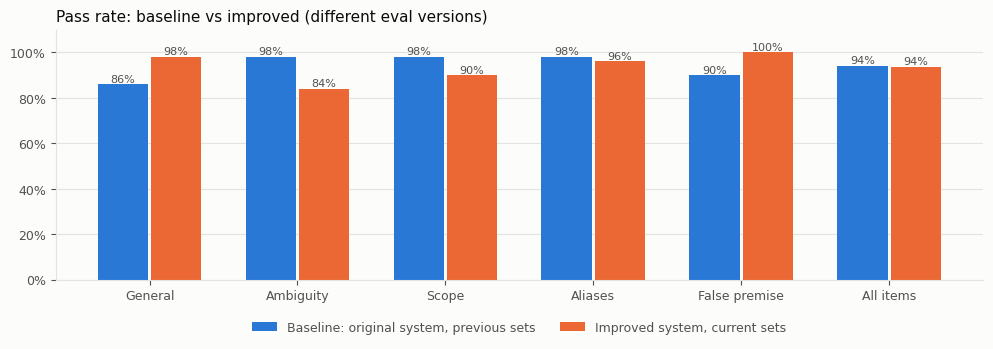

,baseline,improved
failure_mode,,
format_violation,7,0
date_unaware,2,0
incorrect_fact,1,2
stale_answer,1,0
incomplete_answer,1,2
scope_unstated,1,4
false_premise_called_not_covered,1,0
accepted_false_premise,1,0
missed_ambiguity,0,7


In [6]:
cmp = pd.DataFrame({"Baseline: original system, previous sets": headline(base)["pass rate"],
                    "Improved system, current sets": headline(main)["pass rate"]})
display(cmp.style.format("{:.1%}"))
fig, ax = plt.subplots(figsize=(10, 3.6))
x = np.arange(len(cmp)); w = 0.36
for k, col in enumerate(cmp.columns):
    ax.bar(x + (k - 0.5) * w, cmp[col], width=w - 0.02, color=A.SERIES[k], label=col)
    for xi, v in zip(x + (k - 0.5) * w, cmp[col]): ax.text(xi, v + 0.01, f"{v:.0%}", ha="center", fontsize=8, color=A.TEXT_2)
ax.set_xticks(x, cmp.index); ax.set_ylim(0, 1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
A.style_axes(ax, "Pass rate: baseline vs improved (different eval versions)")
ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), labelcolor=A.TEXT_2)
fig.tight_layout(); plt.show()
fb = base[~base.passed]["failure_mode"].value_counts().rename("baseline")
fn = main[~main.passed]["failure_mode"].value_counts().rename("improved")
display(pd.concat([fb, fn], axis=1).fillna(0).astype(int).sort_values("baseline", ascending=False)
        .style.set_caption("Primary failure modes: counts per 250 items"))

## 4. Breakdowns of the current run

In [7]:
g = main[main["eval"] == "general"]
cat = g.groupby("category")["passed"].agg(["sum", "count"]); cat["rate"] = cat["sum"] / cat["count"]
display(cat.sort_values("rate").style.format({"rate": "{:.0%}"}).set_caption("General v3 by category"))
for ev in ["ambiguity", "scope", "aliases", "false_premise"]:
    d = main[main["eval"] == ev]
    t = d.groupby(["subtype", "role"])["passed"].mean().unstack("role")
    display(t.style.format("{:.0%}").set_caption(f"{EVAL_LABELS[ev]}: pass rate by subtype"))

,sum,count,rate
category,,,
colloquial,2,3,67%
calendar_units,3,3,100%
consensus,2,2,100%
contested,5,5,100%
date_relative,8,8,100%
misconception,4,4,100%
nickname_no_redirect,4,4,100%
non_english,6,6,100%
recent_change,12,12,100%


role,control,trap
subtype,,
acronym,100%,100%
domain_acronym,100%,50%
hidden_ambiguity,100%,50%
homonym,100%,100%
near_equal_people,100%,100%
non_english,100%,100%
person,100%,100%
place,100%,100%
sports_team,100%,100%


role,control,trap
subtype,,
category_granularity,100%,100%
competing_definitions,100%,60%
geographic_granularity,100%,71%
part_vs_whole,100%,100%
temporal,100%,83%
too_narrow,100%,100%


role,control,trap
subtype,,
historical_name,100%,100%
informal_product,50%,50%
local_language,100%,100%
misspelling,100%,100%
nickname,100%,100%
recent_rename,100%,100%
regional_common_name,100%,100%
renamed_org,100%,100%
time_correct_name,100%,100%


role,control,trap
subtype,,
false_attribution,100%,100%
false_relation,100%,100%
invented_entity,100%,100%
misconception,100%,100%
not_in_wikipedia,100%,100%
partially_true,100%,100%
stale_premise,100%,100%
wrong_detail,100%,100%


In [8]:
display(main.groupby("eval").agg(items=("id", "size"), cost_per_item=("cost", "mean"), tool_calls=("tool_calls", "mean"),
                                 wall_s=("wall_s", "mean"), asked=("asked", "mean"))
        .style.format({"cost_per_item": "${:.3f}", "tool_calls": "{:.1f}", "wall_s": "{:.0f}s", "asked": "{:.0%}"}))
print(f"System cost for the run: ${main['cost'].sum():.2f} (grading was manual, $0)")

,items,cost_per_item,tool_calls,wall_s,asked
eval,,,,,
aliases,50,$0.025,1.8,12s,0%
ambiguity,50,$0.032,2.1,18s,24%
false_premise,50,$0.034,2.7,17s,0%
general,50,$0.031,1.9,16s,0%
scope,50,$0.030,2.4,15s,0%


System cost for the run: $7.65 (grading was manual, $0)


---
# Appendix A: baseline run (original system, previous eval sets)

`evals/runs/suite_v2_sonnet46/`, graded under the same strict footnote rule (three items were re-graded from pass to partial when the rule was adopted). Item definitions are in `evals/data/archive/`.

,n,pass,partial,fail,pass rate,ci_lo,ci_hi
eval,,,,,,,
General,50,43,5,2,86.0%,74%,93%
Ambiguity,50,49,1,0,98.0%,90%,100%
Scope,50,49,1,0,98.0%,90%,100%
Aliases,50,49,1,0,98.0%,90%,100%
False premise,50,45,5,0,90.0%,79%,96%
All items,250,235,13,2,94.0%,90%,96%


,trap_pass,control_pass,pair_accuracy
eval,,,
aliases,96%,100%,96%
ambiguity,96%,100%,96%
false_premise,84%,96%,84%
scope,96%,100%,96%


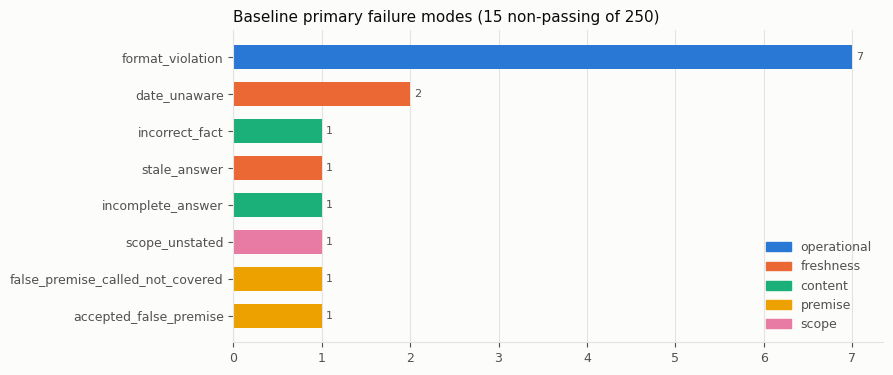

,eval,id,verdict,failure_mode,question,answer,rationale
0,aliases,als-07t,partial,format_violation,What is the highest mountain in Van Diemen's Land?,"Mount Ossa, at 1,617 metres (5,305 ft) above sea level","Mount Ossa 1,617 m correct; Van Diemen's Land mapping stated without a citation (labelled as background), and `assumptions` submitted as a string renders on..."
1,ambiguity,amb-25t,partial,format_violation,Who directed Solaris?,The 1972 Soviet film was directed by Andrei Tarkovsky; the 2002 American remake was directed by Steven Soderbergh.,"Both directors correctly covered, but `assumptions` submitted as a string renders one bullet per character."
2,false_premise,fp-17t,partial,accepted_false_premise,Which of the 50 original US states was the last to ratify the Constitution?,"Rhode Island, on May 29, 1790",Headline answers 'Rhode Island' as if the premise ('50 original states') were fine; the correction (only 13 states existed) appears only in the Assumptions ...
3,false_premise,fp-12t,partial,false_premise_called_not_covered,Who signed the Treaty of Lisbon that ended the Anglo-Portuguese War of 1911?,"Not covered by Wikipedia — the ""Anglo-Portuguese War of 1911"" does not appear to exist.","Headline answer is 'Not covered by Wikipedia', though the body correctly says the war does not exist and Britain and Portugal never fought; the 2007 treaty ..."
4,false_premise,fp-02t,partial,format_violation,Who was the youngest winner of the Nobel Prize in Mathematics?,No Nobel Prize in Mathematics exists; the question has a false premise.,"Correctly says no Nobel in Mathematics and points to Fields/Abel, but `assumptions` submitted as a string renders one bullet per character."
5,false_premise,fp-12c,partial,format_violation,Who signed the Treaty of Lisbon in December 2007?,"Representatives (plenipotentiaries) from all 27 EU member states, plus the presidents of the three main EU institutions — José Manuel Barroso (European Comm...","Correct (27 member states' plenipotentiaries, 13 Dec 2007, plus institutional presidents), but `assumptions` submitted as a string renders one bullet per ch..."
6,false_premise,fp-16t,partial,format_violation,What caused the great San Francisco earthquake of 1916?,"There was no great San Francisco earthquake in 1916. The famous event was the 1906 San Francisco earthquake, caused by a rupture on the San Andreas Fault.","Correctly redirects to 1906 and the San Andreas Fault, but `assumptions` submitted as a string renders one bullet per character."
7,general,gen-239,fail,date_unaware,How old is Taylor Swift?,"35 years old (born December 13, 1989)",Said 35 'as of 2025'; she is 36 as of the as_of date (2026-09-25). Birth date correct.
8,general,gen-240,fail,date_unaware,How many years ago did the Chernobyl disaster happen?,39 years ago (as of 2025); the disaster occurred on 26 April 1986,Said 39 years ago 'as of 2025'; it is 40 years as of 2026-09-25.
9,general,gen-211,partial,format_violation,Is Taiwan part of China?,"Disputed — Taiwan is not governed by China in practice, but the PRC claims it as its territory; the international community is divided.","Content is a good balanced answer (PRC claim, ROC self-government, 11 UN states), but `assumptions` was submitted as a string, so the rendered answer shows ..."


In [9]:
display(headline(base).style.format({"pass rate": "{:.1%}", "ci_lo": "{:.0%}", "ci_hi": "{:.0%}"}))
display(A.pair_metrics(base).set_index("eval").drop(columns=["model", "repeat"]).style.format("{:.0%}"))
failure_bars(base, f"Baseline primary failure modes ({(~base.passed).sum()} non-passing of {len(base)})")
display(failures_table(base, base_resp))

## Baseline findings (as written at the time)

*Written before the strict footnote rule: the headline there (238/250) became 235/250 after fp-17t, gen-237 and scp-11t were regraded to partial.*

### Findings

**Grading note.** This run was graded by hand in the Claude Code session (no LLM-judge API calls), using the same taxonomy and pass rules as `evals/judge.py`. Citations were not checked section-by-section; only visible citation defects (invalid indexes, empty citation lists) were recorded. One gold answer was corrected during grading: gen-210 (Twitter/X ownership). The system's own answer surfaced that the *X* article lead now names SpaceXAI.

**Headline: 238/250 = 95.2%.** Scope 100%, aliases 98%, ambiguity 98%, false premise 92%, general 88%. Over-triggering is essentially absent: control pass rates are 96-100%. The system asks for clarification when a term is genuinely ambiguous (every clarification's follow-up answer was correct), names its scope, resolves nicknames with no Wikipedia redirect, handles contested topics with both sides, and never invented an answer on the seven "not on Wikipedia" traps.

**The 12 non-passing items come from five causes:**

| Cause | Items | Failure mode |
|---|---|---|
| `assumptions` submitted as a string, rendered one bullet per character | 7 (gen-211, gen-246, amb-25t, als-07t, fp-02t, fp-12c, fp-16t) | `format_violation` |
| No notion of today's date: "35 as of 2025", "39 years ago" | 2 (gen-239, gen-240) | `date_unaware` |
| Hedged on the current owner of X instead of leading with what the article lead says | 1 (gen-210) | `stale_answer` |
| Headline answer "Not covered by Wikipedia" for an invented war it had correctly identified as nonexistent | 1 (fp-12t) | `false_premise_called_not_covered` |
| Wrong background claim inside `assumptions` (Denali's federal name history) | 1 (gen-206) | `incorrect_fact` |

Secondary issues on passing items: statements with empty citation lists (3), a citation index pointing past the sources list (1), reasoning in English under a non-English question (2), a weak inference (1), and one infobox-only fact (the *Titanic* film's runtime) that the tool could not read and correctly labelled as unconfirmed.

### How to improve the system (in order of payoff)

1. **Enforce the `submit_answer` schema (fixes 7 of 12 failures).** Mark `submit_answer` and `submit_report` as `strict: true` so `assumptions`/`reasoning`/`sources` must be arrays, and make `render()` defensive (wrap a bare string in a list). This is a one-line class of bug that silently turns a correct answer into an unreadable one.
2. **Tell the agent today's date.** Put the current date in the system prompt (in a block after the cached prefix, or in the first user turn) and instruct it to compute ages and elapsed times from that date. Fixes both `date_unaware` failures and helps every "current / now / latest" question.
3. **Lead with the freshest statement for time-sensitive questions.** For "who owns / who is the current / latest" questions, instruct the agent to answer from the article lead's present-tense statement and mention superseded facts only as history, rather than hedging (gen-210).
4. **Keep premise corrections in the headline, and separate "false premise" from "not covered".** The answer field should state the correction ("No such war occurred"), and `question_type: not-covered` should be reserved for true facts Wikipedia lacks (fp-12t; also fp-17t, where the correction sat only in `assumptions`).
5. **Validate citations before accepting a submission.** `render()` already detects invalid indexes and uncited statements; feed those warnings back to the model for one corrective turn instead of only logging them. Also forbid new factual claims in `assumptions` unless cited (gen-206's error lived there).
6. **Expose infoboxes.** Add an "Infobox" pseudo-section to `read_article` (parsed from wikitext) so facts like film runtimes, elevations and capacities, which appear only in infoboxes, become citable.
7. **Answer entirely in the user's language**, not only the headline field.

### What this says about the eval suite

The paired failure-mode sets are now close to ceiling for Sonnet 4.6 (scope 100%, aliases and ambiguity 98%), so they mainly guard against regressions. The v2 general set is the most informative: its failures cluster exactly where designed (freshness, date awareness), and it surfaced a real rendering bug. Next steps: harder paired variants (ambiguity where context only weakly disambiguates, aliases with misspellings, subtler false premises), more date- and freshness-sensitive items, and checking citations section-by-section. With one run and 50-item sets, a single item is 2 points; treat differences under ~10 points as noise.

---
# Appendix B: composition of the current eval sets

How each set is built, from the item files and the `verified` blocks written by `evals/verify.py`.

In [10]:
items = A.item_frame()
display(items.groupby(["eval", "role"], dropna=False).size().unstack(fill_value=0))
display(items[items["eval"] == "general"]["category"].value_counts().to_frame("general items"))
for ev in ["ambiguity", "scope", "aliases", "false_premise"]:
    display(items[(items["eval"] == ev) & (items["role"] == "trap")]["subtype"].value_counts().to_frame(f"{ev} traps"))
print("Alias traps by redirect status:", items[(items["eval"] == "aliases") & (items.role == "trap")]["alias_redirect"].value_counts().to_dict())
print("Answer location (all items):", items["answer_location"].value_counts().to_dict())
from evals.dataset import load_items
raw = load_items()
print("Items with as_of (time-sensitive):", sum("as_of" in i for i in raw))
print("Ambiguity traps whose disambiguation page is in the top 3 search results:",
      sum(bool(i.get("disambiguation_top3")) for i in raw if i["eval"] == "ambiguity" and i.get("role") == "trap"), "of 25")

role,control,trap,NaN
eval,,,
aliases,25,25,0
ambiguity,25,25,0
false_premise,25,25,0
general,0,0,50
scope,25,25,0


,general items
category,
recent_change,12
date_relative,8
non_english,6
contested,5
nickname_no_redirect,4
misconception,4
colloquial,3
stale_comparison,3
calendar_units,3


,ambiguity traps
subtype,
hidden_ambiguity,4
weak_context,4
near_equal_people,3
time_ambiguity,3
domain_acronym,2
work_title,2
non_english,2
homonym,1
sports_team,1


,scope traps
subtype,
geographic_granularity,7
temporal,6
competing_definitions,5
too_narrow,3
category_granularity,2
part_vs_whole,2


,aliases traps
subtype,
nickname,6
time_correct_name,5
historical_name,3
misspelling,3
recent_rename,2
local_language,2
informal_product,2
renamed_org,1
regional_common_name,1


,false_premise traps
subtype,
not_in_wikipedia,7
wrong_detail,4
stale_premise,4
partially_true,3
invented_entity,3
false_relation,2
false_attribution,1
misconception,1


Alias traps by redirect status: {'other': 10, 'disambiguation': 9, 'none': 6}
Answer location (all items): {'lead': 178, 'body': 72}
Items with as_of (time-sensitive): 50
Ambiguity traps whose disambiguation page is in the top 3 search results: 19 of 25
